# Independent Component Analysis from Scratch

Three people talk at once in a room with three microphones. Each microphone records a different weighted sum of
the three voices, and the weights are unknown. Independent component analysis recovers the voices from the
recordings, using nothing but the assumption that the speakers are statistically independent of one another.

The model is a linear mixture,

$$\mathbf{x} = A\mathbf{s},$$

with $\mathbf{s} \in \mathbb{R}^{D}$ the unobserved sources, $A \in \mathbb{R}^{D\times D}$ the unknown mixing
matrix, and $\mathbf{x}$ the observed signals. Fitting means finding an unmixing matrix $W$ such that the rows
of $W\mathbf{x}$ are as statistically independent as they can be made. Nothing else is given: not $A$, not the
distributions of the sources, not their order or scale.

**This is not the problem PCA solves, and the difference is the whole point of the method.** PCA produces
*uncorrelated* components. Uncorrelatedness is a statement about second moments,
$\mathbb{E}[z_iz_j] = \mathbb{E}[z_i]\mathbb{E}[z_j]$, and it is far weaker than independence, which requires
$p(z_1,\dots,z_D) = \prod_j p(z_j)$ and therefore constrains every moment at once. `pca.ipynb` ends by measuring
that gap: on a mixture of two uniform sources the PCA scores are uncorrelated to 8.7e-16 and still carry 0.257
nats of mutual information against the sources' 0.013. This notebook closes it.

What gets built:

- the blind source separation setup, with three synthetic signals whose ground truth is known, so separation can
  actually be scored rather than eyeballed;
- the argument that **Gaussian sources cannot be separated at all**, which is the single most important fact
  about ICA and is demonstrated numerically rather than asserted;
- non-Gaussianity as the contrast function, via kurtosis and via a negentropy approximation;
- centring and whitening, the preprocessing PCA provides, and the proof that after whitening the remaining
  mixing matrix must be a rotation;
- `Fast_ICA`, the fixed-point iteration derived by hand, with the `tanh`, cube and Gaussian nonlinearities and
  both deflationary and symmetric orthogonalisation;
- the same mixture put through PCA, which does not separate it, side by side with ICA, which does;
- the two ambiguities that are inherent to the model: the order and the scale of the components are not
  identifiable, and no amount of data fixes that.

The last section runs ICA on the UCI handwritten digits used by `pca.ipynb` and `tsne.ipynb`, where the mixing
matrix is not known but the two methods can still be compared on the same 64 pixels.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

SEED = 0
np.random.seed(SEED)

COLOURS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']
blue, orange, green, gold, purple = COLOURS

notebook_start = time.time()
print('numpy', np.__version__)

numpy 2.4.6


## The mixture

Three sources are generated over 2,000 time steps: a sine wave, a square wave and a sawtooth. They are chosen
because they are strongly non-Gaussian in three different ways and because the ground truth is available, so
the recovered signals can be scored against it. Each is standardised to zero mean and unit variance, which
costs nothing — the scale of a source is not identifiable anyway, as the last section shows.

They are mixed by a fixed $3\times3$ matrix

$$A = \begin{pmatrix} 1.0 & 1.0 & 1.0 \\ 0.5 & 2.0 & 1.0 \\ 1.5 & 1.0 & 2.0 \end{pmatrix},$$

so each observed channel is a different combination of all three sources, and no observed channel resembles any
single source. The `x = s @ A.T` convention keeps one sample per row, matching the rest of this repository.

The **excess kurtosis** of a standardised variable,

$$\operatorname{kurt}(z) = \mathbb{E}[z^4] - 3,$$

is zero for a Gaussian, negative for a flat-topped distribution and positive for a spiky one. It is printed for
the sources and for the mixtures below, and the pattern in those numbers is the mechanism ICA runs on.

In [2]:
n_samples = 2000
t = np.linspace(0, 8, n_samples)

s_sine = np.sin(2 * t)
s_square = np.sign(np.sin(3 * t))
s_saw = 2 * ((t * 0.7) % 1.0) - 1.0

S_true = np.column_stack([s_sine, s_square, s_saw])
S_true = (S_true - S_true.mean(axis=0)) / S_true.std(axis=0)

A_true = np.array([[1.0, 1.0, 1.0],
                   [0.5, 2.0, 1.0],
                   [1.5, 1.0, 2.0]])
X_mix = S_true @ A_true.T

source_names = ['sine', 'square', 'sawtooth']


def excess_kurtosis(Z):
    Z = (Z - Z.mean(axis=0)) / Z.std(axis=0)
    return (Z ** 4).mean(axis=0) - 3.0


print('sources ', S_true.shape, '  mixtures', X_mix.shape)
print()
print('%-12s %14s' % ('signal', 'excess kurtosis'))
for j, name in enumerate(source_names):
    print('%-12s %14.4f' % ('source: ' + name, excess_kurtosis(S_true)[j]))
for j in range(3):
    print('%-12s %14.4f' % ('mixture %d' % (j + 1), excess_kurtosis(X_mix)[j]))
print()
print('every mixture is closer to zero kurtosis - closer to Gaussian - than the sources it contains')

sources  (2000, 3)   mixtures (2000, 3)

signal       excess kurtosis
source: sine        -1.3655
source: square        -1.9908
source: sawtooth        -1.1508
mixture 1           -0.4359
mixture 2           -1.1741
mixture 3           -0.4197

every mixture is closer to zero kurtosis - closer to Gaussian - than the sources it contains


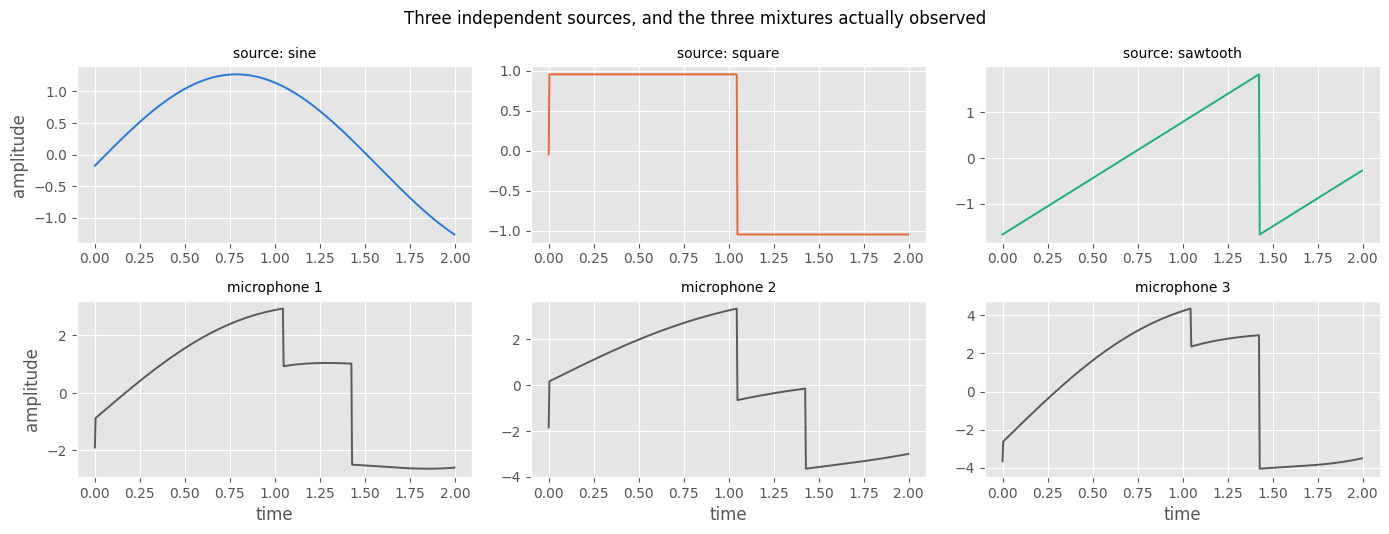

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(14, 5.4))

window = slice(0, 500)
for j in range(3):
    ax[0, j].plot(t[window], S_true[window, j], color=COLOURS[j], lw=1.4)
    ax[0, j].set_title('source: %s' % source_names[j], fontsize=10)
    ax[1, j].plot(t[window], X_mix[window, j], color='0.35', lw=1.4)
    ax[1, j].set_title('microphone %d' % (j + 1), fontsize=10)
    ax[1, j].set_xlabel('time')

ax[0, 0].set_ylabel('amplitude')
ax[1, 0].set_ylabel('amplitude')
plt.suptitle('Three independent sources, and the three mixtures actually observed')
plt.tight_layout()
plt.show()

## Why Gaussian sources are impossible to separate

This is the fact to understand before anything else, because it explains why the whole method is organised
around non-Gaussianity.

Suppose the sources are independent standard Gaussians, $\mathbf{s} \sim \mathcal{N}(\mathbf{0}, I)$, and let
$R$ be any orthogonal matrix, $R^\top R = I$. Put $\mathbf{s}' = R\mathbf{s}$. Then $\mathbf{s}'$ is Gaussian,
being a linear map of a Gaussian, with

$$\mathbb{E}[\mathbf{s}'] = \mathbf{0}, \qquad
\operatorname{Cov}(\mathbf{s}') = R\,I\,R^\top = I,$$

so $\mathbf{s}' \sim \mathcal{N}(\mathbf{0}, I)$ as well: **a rotation of independent standard Gaussians is
again independent standard Gaussians.** Its density factorises exactly as the original's does. The rotated
variables are just as independent as the ones we started with.

Now the consequence for the model. Observing $\mathbf{x} = A\mathbf{s}$, write

$$\mathbf{x} = A\mathbf{s} = (AR^\top)(R\mathbf{s}) = A'\mathbf{s}'.$$

The pair $(A', \mathbf{s}')$ explains the observations exactly as well as $(A, \mathbf{s})$ does, with sources
that are exactly as independent. The density of $\mathbf{x}$ is $\mathcal{N}(\mathbf{0}, AA^\top)$ and
$A'A'^\top = AR^\top RA^\top = AA^\top$, so the two are not merely both plausible, they are the *same
distribution*. No amount of data distinguishes them, because there is nothing to distinguish. The mixing matrix
is identifiable only up to an arbitrary rotation, and independence — the only criterion ICA has — cannot pick
one out.

The escape is that this argument uses the Gaussian in an essential way. For non-Gaussian sources, rotating
destroys independence, and that is what makes recovery possible at all.

The demonstration below measures it. Two independent sources are drawn — Gaussian in one case, uniform in the
other — the pair is rotated by an angle $\theta$, and the mutual information between the two rotated
coordinates is estimated from a 2-D histogram,

$$I(z_1;z_2) = \sum_{a,b} p_{ab}\log\frac{p_{ab}}{p_ap_b},$$

which is zero exactly when the coordinates are independent. For the uniform pair this has sharp minima at 0 and
90 degrees, the true axes, and rises steeply in between. For the Gaussian pair it is flat: every rotation is as
independent as every other, so there is no minimum to find.

In [4]:
def mutual_information(a, b, bins=24):
    # histogram estimate of I(a; b) in nats
    H, _, _ = np.histogram2d(a, b, bins=bins)
    P = H / H.sum()
    pa = P.sum(axis=1, keepdims=True)
    pb = P.sum(axis=0, keepdims=True)
    nz = P > 0
    return float((P[nz] * np.log(P[nz] / (pa @ pb)[nz])).sum())


def rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


angles = np.linspace(0, np.pi / 2, 91)
curves, kurt_curves = {}, {}

for name in ['gaussian', 'uniform']:
    r = np.random.default_rng(5)
    src = r.normal(size=(20000, 2)) if name == 'gaussian' else r.uniform(-1, 1, size=(20000, 2))
    src = (src - src.mean(axis=0)) / src.std(axis=0)
    curves[name] = np.array([mutual_information(*(src @ rotation(a).T).T) for a in angles])
    kurt_curves[name] = np.array([abs(excess_kurtosis(src @ rotation(a).T)[0]) for a in angles])
    print('%-9s mutual information over all rotations: min %.5f  max %.5f  spread %.5f nats'
          % (name, curves[name].min(), curves[name].max(), curves[name].max() - curves[name].min()))

print()
for name in ['gaussian', 'uniform']:
    print('%-9s |excess kurtosis| of the first coordinate: min %.4f  max %.4f'
          % (name, kurt_curves[name].min(), kurt_curves[name].max()))

gaussian  mutual information over all rotations: min 0.00923  max 0.01162  spread 0.00239 nats
uniform   mutual information over all rotations: min 0.01353  max 0.26731  spread 0.25378 nats

gaussian  |excess kurtosis| of the first coordinate: min 0.0009  max 0.0379
uniform   |excess kurtosis| of the first coordinate: min 0.5999  max 1.1997


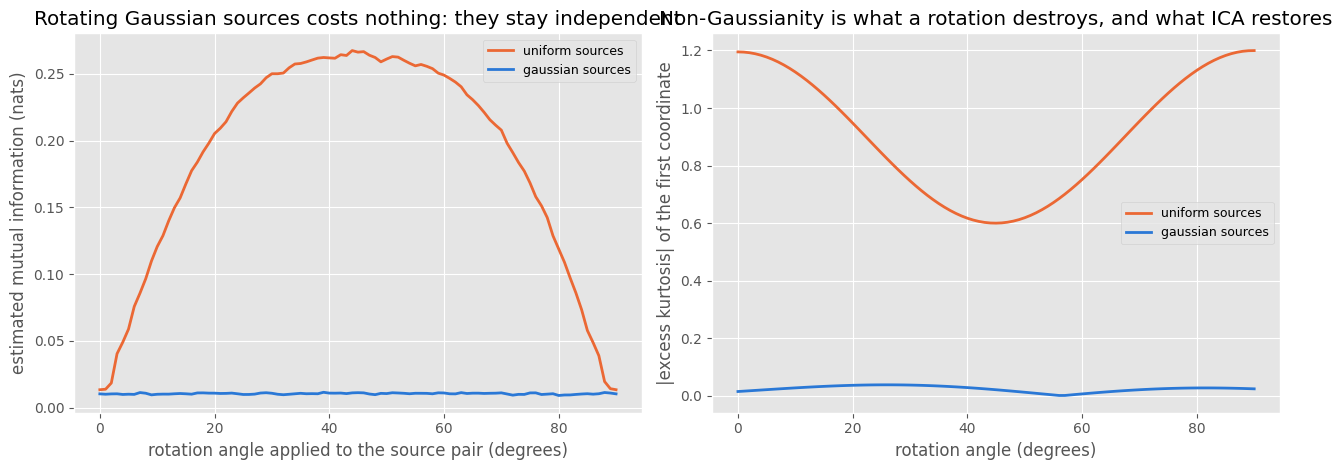

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

deg = np.degrees(angles)
for name, col in [('uniform', orange), ('gaussian', blue)]:
    ax[0].plot(deg, curves[name], color=col, lw=2, label='%s sources' % name)
    ax[1].plot(deg, kurt_curves[name], color=col, lw=2, label='%s sources' % name)

ax[0].set_xlabel('rotation angle applied to the source pair (degrees)')
ax[0].set_ylabel('estimated mutual information (nats)')
ax[0].set_title('Rotating Gaussian sources costs nothing: they stay independent')
ax[0].legend(fontsize=9)

ax[1].set_xlabel('rotation angle (degrees)')
ax[1].set_ylabel('|excess kurtosis| of the first coordinate')
ax[1].set_title('Non-Gaussianity is what a rotation destroys, and what ICA restores')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

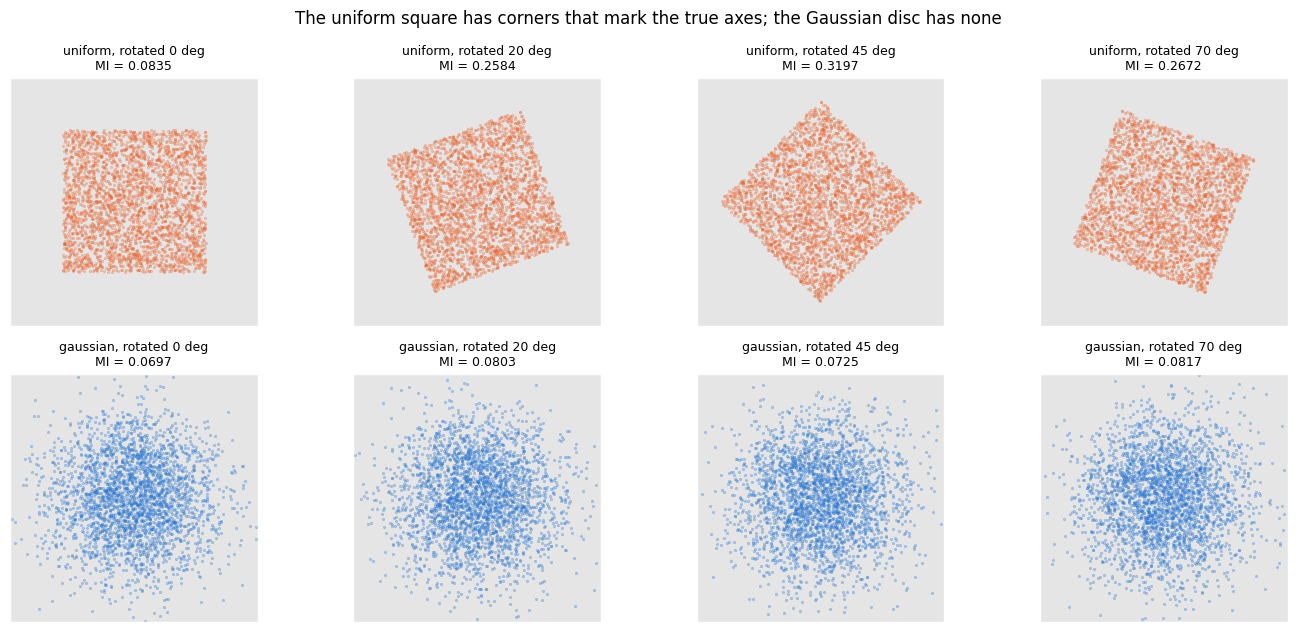

In [6]:
fig, ax = plt.subplots(2, 4, figsize=(14, 6.4))

for row, name in enumerate(['uniform', 'gaussian']):
    r = np.random.default_rng(5)
    src = r.normal(size=(3000, 2)) if name == 'gaussian' else r.uniform(-1, 1, size=(3000, 2))
    src = (src - src.mean(axis=0)) / src.std(axis=0)
    for col, theta in enumerate([0, 20, 45, 70]):
        Z = src @ rotation(np.radians(theta)).T
        a = ax[row, col]
        a.scatter(Z[:, 0], Z[:, 1], s=3, alpha=0.3, color=orange if name == 'uniform' else blue)
        a.set_title('%s, rotated %d deg\nMI = %.4f' % (name, theta, mutual_information(Z[:, 0], Z[:, 1])),
                    fontsize=9)
        a.set_xlim(-3, 3); a.set_ylim(-3, 3)
        a.set_aspect('equal')
        a.set_xticks([]); a.set_yticks([])

plt.suptitle('The uniform square has corners that mark the true axes; the Gaussian disc has none')
plt.tight_layout()
plt.show()

The uniform pair fills a square, and the square has corners. Rotating it moves the corners, and the corners are
what the mutual information can see — it varies from 0.014 to 0.267 nats over the rotations, with the minimum
exactly at the true axes. The Gaussian pair fills a disc, which looks identical from every angle: the mutual
information varies by 0.002 nats across all rotations, which is the noise floor of the histogram estimate, and
its shallow maximum sits at 39 degrees for no reason other than sampling. There is no signal there to optimise.

The same statement in terms of kurtosis: for the uniform pair the magnitude of the excess kurtosis of a
projection ranges from 0.60 to 1.20 as the direction turns, so the direction of maximum non-Gaussianity is well
defined. For the Gaussian pair it never exceeds 0.038 and has no meaningful structure.

**In practice this means ICA needs at most one Gaussian source.** If two or more sources are Gaussian, the
rotation mixing them is unrecoverable, though the rest of the model may still be.

## Non-Gaussianity as the contrast function

Why does maximising non-Gaussianity find a source? Consider any linear combination of the observed signals,

$$y = \mathbf{w}^\top\mathbf{x} = \mathbf{w}^\top A\mathbf{s} = \mathbf{q}^\top\mathbf{s}
= \sum_j q_j s_j, \qquad \mathbf{q} = A^\top\mathbf{w}.$$

Whatever $\mathbf{w}$ is chosen, $y$ is a weighted sum of the independent sources. The central limit theorem
says a sum of independent random variables is more Gaussian than the individual terms, and the more terms
contribute the more Gaussian it gets. So $y$ is *least* Gaussian when $\mathbf{q}$ has a single non-zero entry —
which is exactly when $y$ is one of the sources. The printed kurtoses above already show this in one direction:
the sources have excess kurtosis $-1.365$, $-1.991$ and $-1.151$, while the three mixtures, each a sum of all
three, sit at $-0.436$, $-1.174$ and $-0.420$, all closer to the Gaussian value of zero.

**Maximising non-Gaussianity of $\mathbf{w}^\top\mathbf{x}$ therefore recovers a source.** What remains is to
choose a measure of non-Gaussianity that can be optimised.

**Kurtosis** is the obvious one, $\operatorname{kurt}(y) = \mathbb{E}[y^4]-3$ for unit variance $y$. It is
simple and it is zero for a Gaussian, but the fourth power makes it very sensitive to outliers: a single
extreme sample moves it a great deal.

**Negentropy** is the principled one. Among all distributions with a given variance the Gaussian has the largest
differential entropy, so

$$J(y) = H(y_{\text{gauss}}) - H(y) \ge 0,$$

with equality only for a Gaussian. Negentropy is invariant to invertible linear transformation and is not
dominated by the tails, but computing it requires the density of $y$, which is not available. Hyvärinen's
approximation replaces it with

$$J(y) \;\propto\; \big[\,\mathbb{E}\{G(y)\} - \mathbb{E}\{G(\nu)\}\,\big]^2,$$

where $\nu$ is a standard Gaussian and $G$ is a smooth non-quadratic function. Two standard choices are

$$G_1(u) = \tfrac{1}{a}\log\cosh(a u), \qquad G_2(u) = -e^{-u^2/2},$$

with $a = 1$ used throughout here. Taking $G(u) = u^4/4$ recovers kurtosis exactly, so kurtosis is the special
case of this family that grows fastest and is therefore the least robust member of it.

What the algorithm actually needs is the derivative $g = G'$, and its derivative $g'$:

| name | $G(u)$ | $g(u)$ | $g'(u)$ |
|---|---|---|---|
| `logcosh` | $\log\cosh u$ | $\tanh u$ | $1 - \tanh^2 u$ |
| `cube` | $u^4/4$ | $u^3$ | $3u^2$ |
| `gauss` | $-e^{-u^2/2}$ | $u\,e^{-u^2/2}$ | $(1-u^2)e^{-u^2/2}$ |

`logcosh` is the default because $\tanh$ saturates, so a large value of $u$ contributes a bounded amount and
outliers cannot dominate. `cube` is kurtosis and converges fast on strongly super-Gaussian data. `gauss` is even
more strongly saturating and is the choice when the data is very heavy-tailed.

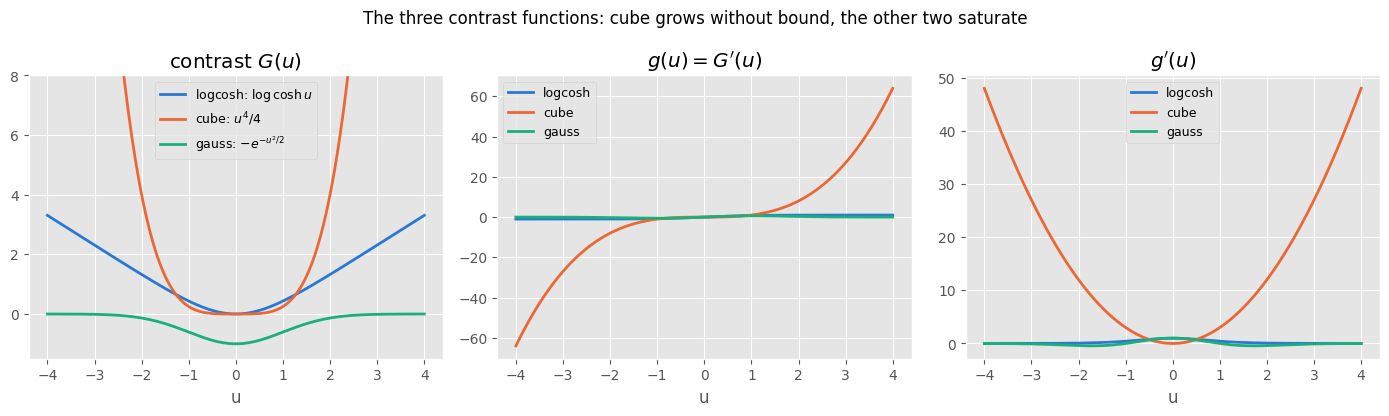

In [7]:
def g_logcosh(u):
    tanh_u = np.tanh(u)
    return tanh_u, 1.0 - tanh_u ** 2


def g_cube(u):
    return u ** 3, 3.0 * u ** 2


def g_gauss(u):
    e = np.exp(-u ** 2 / 2.0)
    return u * e, (1.0 - u ** 2) * e


NONLINEARITIES = {'logcosh': g_logcosh, 'cube': g_cube, 'gauss': g_gauss}

grid = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

labels = {'logcosh': r'$\log\cosh u$', 'cube': r'$u^4/4$', 'gauss': r'$-e^{-u^2/2}$'}
G_funcs = {'logcosh': lambda u: np.log(np.cosh(u)),
           'cube': lambda u: u ** 4 / 4,
           'gauss': lambda u: -np.exp(-u ** 2 / 2)}

for (name, fn), col in zip(NONLINEARITIES.items(), COLOURS):
    ax[0].plot(grid, G_funcs[name](grid), color=col, lw=2, label='%s: %s' % (name, labels[name]))
    ax[1].plot(grid, fn(grid)[0], color=col, lw=2, label=name)
    ax[2].plot(grid, fn(grid)[1], color=col, lw=2, label=name)

ax[0].set_ylim(-1.5, 8)
ax[0].set_title(r'contrast $G(u)$')
ax[1].set_title(r"$g(u) = G'(u)$")
ax[2].set_title(r"$g'(u)$")
for a in ax:
    a.set_xlabel('u')
    a.legend(fontsize=9)

plt.suptitle('The three contrast functions: cube grows without bound, the other two saturate')
plt.tight_layout()
plt.show()

## Centring and whitening

Two preprocessing steps come before the iteration, and both are PCA operations.

**Centring** removes the mean, $\tilde{\mathbf{x}} = \mathbf{x} - \bar{\mathbf{x}}$. The mixing model has no
offset term, so the mean has to be taken out and can be added back afterwards if the sources' means are wanted.

**Whitening** transforms $\tilde{\mathbf{x}}$ so that its covariance is the identity. Using the
eigendecomposition of the covariance $\Sigma = V\Lambda V^\top$ from `pca.ipynb`,

$$\mathbf{z} = K\tilde{\mathbf{x}}, \qquad K = \Lambda^{-1/2}V^\top,
\qquad \operatorname{Cov}(\mathbf{z}) = K\Sigma K^\top
= \Lambda^{-1/2}V^\top V\Lambda V^\top V\Lambda^{-1/2} = I.$$

This is exactly PCA followed by a per-component rescaling, and it is also where the dimension is chosen: keeping
the leading $k$ eigenvectors both whitens and reduces, in one step.

Whitening earns its place through the following observation. In the whitened coordinates the mixing matrix is
$\tilde{A} = KA$, and since $\operatorname{Cov}(\mathbf{s}) = I$ and $\operatorname{Cov}(\mathbf{z}) = I$,

$$I = \operatorname{Cov}(\mathbf{z}) = \tilde{A}\operatorname{Cov}(\mathbf{s})\tilde{A}^\top
= \tilde{A}\tilde{A}^\top,$$

so **$\tilde{A}$ is orthogonal**. The search space collapses from the $D^2$ free entries of a general matrix to
the $D(D-1)/2$ of a rotation: 3 parameters instead of 9 for three sources, 190 instead of 400 for twenty. It
also means the unmixing matrix $W$ to be estimated is orthogonal, so its rows can be kept orthonormal
throughout, which is what makes the fixed-point iteration below stable.

Whitening is also where the connection to PCA is sharpest, and where the two methods visibly diverge. Whitening
already makes the components uncorrelated; it is only ever a rotation away from the answer. But there are
infinitely many rotations of a whitened dataset, all equally uncorrelated, and only one of them is independent.
PCA has no way to choose among them. ICA chooses by non-Gaussianity.

In [8]:
def whiten(X, k=None):
    # centre, then transform so the covariance is the identity; K is the whitening matrix
    mean = X.mean(axis=0)
    Xc = X - mean
    cov = Xc.T @ Xc / (len(X) - 1)
    w, V = np.linalg.eigh(cov)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]
    if k is not None:
        w, V = w[:k], V[:, :k]
    K = (V / np.sqrt(w)).T
    return Xc @ K.T, K, mean, w


Z_white, K_white, mean_mix, eigvals_mix = whiten(X_mix)

A_tilde = K_white @ A_true
cov_sources = np.cov(S_true.T, ddof=1)

print('covariance of the whitened data, max |Cov - I|:      %.2e'
      % np.abs(np.cov(Z_white.T, ddof=1) - np.eye(3)).max())
print('is K A orthogonal?  max |(KA)(KA)^T - I|:            %.2e'
      % np.abs(A_tilde @ A_tilde.T - np.eye(3)).max())
print('sample covariance of the sources, max |Cov(s) - I|:  %.2e'
      % np.abs(cov_sources - np.eye(3)).max())
print()
print('sample covariance of the three sources:')
print(np.round(cov_sources, 5))
print()

# the same check with sources made exactly uncorrelated in this sample
L_src = np.linalg.cholesky(cov_sources)
S_exact = S_true @ np.linalg.inv(L_src).T
_, K_exact, _, _ = whiten(S_exact @ A_true.T)
A_exact = K_exact @ A_true
print('with the residual sample correlation between the sources removed:')
print('  max |Cov(s) - I|                                   %.2e'
      % np.abs(np.cov(S_exact.T, ddof=1) - np.eye(3)).max())
print('  max |(KA)(KA)^T - I|                               %.2e'
      % np.abs(A_exact @ A_exact.T - np.eye(3)).max())
print()
print('K A, the mixing matrix seen in whitened coordinates:')
print(np.round(A_tilde, 4))
print()
print('free parameters in a general D x D matrix: %d' % 9)
print('free parameters in a D x D rotation:       %d' % 3)
print('at D = 20 those become %d and %d' % (400, 20 * 19 // 2))

covariance of the whitened data, max |Cov - I|:      4.88e-14
is K A orthogonal?  max |(KA)(KA)^T - I|:            5.66e-02
sample covariance of the sources, max |Cov(s) - I|:  8.62e-02

sample covariance of the three sources:
[[ 1.0005   0.08617  0.01288]
 [ 0.08617  1.0005  -0.00906]
 [ 0.01288 -0.00906  1.0005 ]]

with the residual sample correlation between the sources removed:
  max |Cov(s) - I|                                   6.66e-16
  max |(KA)(KA)^T - I|                               4.73e-14

K A, the mixing matrix seen in whitened coordinates:
[[-0.4625 -0.5894 -0.6249]
 [ 0.487  -0.8108  0.4024]
 [-0.7457 -0.0475  0.6688]]

free parameters in a general D x D matrix: 9
free parameters in a D x D rotation:       3
at D = 20 those become 400 and 190


The whitened data has identity covariance to 4.9e-14, as it must — that is what the transformation was
constructed to do. The orthogonality of $KA$ is a different matter: it comes out at 5.66e-02 rather than at
machine precision, and the reason is in the printed source covariance.

The derivation assumed $\operatorname{Cov}(\mathbf{s}) = I$. The sources here are *independent by
construction* but they are deterministic waveforms observed over a finite window, and over this particular
window the sine and the square wave have a sample correlation of 0.086. Independence in the generating process
does not force the finite-sample correlation to be exactly zero, and it is the sample covariance that the
identity $\tilde{A}\tilde{A}^\top = I$ actually depends on. Removing that residual correlation — by
decorrelating the sources with a Cholesky factor before mixing — brings $\lvert(KA)(KA)^\top - I\rvert$ down to
4.7e-14, which confirms that the 5.66e-02 is the sample correlation showing through and not an error in the
algebra.

This is worth noticing rather than hiding, because it is exactly the slack that FastICA has to work within. The
algorithm assumes the remaining transformation is a rotation and constrains its iterates to be orthonormal; the
data only satisfies that assumption up to sampling. The residual is one of the reasons the recovered
correlations below are 0.99 rather than 1.00.

## The FastICA fixed-point iteration, derived

The problem, for one component, is

$$\max_{\mathbf{w}}\; \mathbb{E}\{G(\mathbf{w}^\top\mathbf{z})\}
\quad\text{subject to}\quad \lVert\mathbf{w}\rVert = 1,$$

with $\mathbf{z}$ whitened. The constraint is $\lVert\mathbf{w}\rVert = 1$ because in whitened coordinates
$\operatorname{Var}(\mathbf{w}^\top\mathbf{z}) = \mathbf{w}^\top\mathbf{w}$, so a unit vector is exactly a unit
variance output, and the contrast is only meaningful at fixed variance.

**Stationarity.** The Lagrangian is
$\mathcal{L} = \mathbb{E}\{G(\mathbf{w}^\top\mathbf{z})\} - \tfrac{\beta}{2}(\mathbf{w}^\top\mathbf{w}-1)$, so
with $g = G'$,

$$\frac{\partial\mathcal{L}}{\partial\mathbf{w}} = \mathbb{E}\{\mathbf{z}\,g(\mathbf{w}^\top\mathbf{z})\} - \beta\mathbf{w} = \mathbf{0}.$$

Write this as $F(\mathbf{w}) = \mathbb{E}\{\mathbf{z}g(\mathbf{w}^\top\mathbf{z})\} - \beta\mathbf{w} = \mathbf{0}$
and solve it by Newton's method rather than by gradient ascent.

**The Jacobian.** Differentiating $F$ again,

$$\frac{\partial F}{\partial\mathbf{w}} = \mathbb{E}\{\mathbf{z}\mathbf{z}^\top g'(\mathbf{w}^\top\mathbf{z})\} - \beta I.$$

The first term is a full $D\times D$ matrix and inverting it every iteration would be expensive. Here the
whitening pays off a second time. Because $\mathbf{z}$ is white, $\mathbf{z}$ and $g'(\mathbf{w}^\top\mathbf{z})$
are approximately uncorrelated in the sense that

$$\mathbb{E}\{\mathbf{z}\mathbf{z}^\top g'(\mathbf{w}^\top\mathbf{z})\}
\approx \mathbb{E}\{\mathbf{z}\mathbf{z}^\top\}\,\mathbb{E}\{g'(\mathbf{w}^\top\mathbf{z})\}
= \mathbb{E}\{g'(\mathbf{w}^\top\mathbf{z})\}\,I,$$

turning the Jacobian into a scalar multiple of the identity,
$(\mathbb{E}\{g'(\mathbf{w}^\top\mathbf{z})\} - \beta)I$, which is trivially inverted.

**The Newton step.** With that approximation,

$$\mathbf{w}^{+} = \mathbf{w} - \frac{\mathbb{E}\{\mathbf{z}g(\mathbf{w}^\top\mathbf{z})\} - \beta\mathbf{w}}
{\mathbb{E}\{g'(\mathbf{w}^\top\mathbf{z})\} - \beta}.$$

Multiplying both sides by the scalar $\beta - \mathbb{E}\{g'\}$ — which is allowed because $\mathbf{w}$ is
renormalised immediately afterwards, so any non-zero scaling is irrelevant — collapses this to

$$\boxed{\;\mathbf{w}^{+} = \mathbb{E}\{\mathbf{z}\,g(\mathbf{w}^\top\mathbf{z})\}
- \mathbb{E}\{g'(\mathbf{w}^\top\mathbf{z})\}\,\mathbf{w}, \qquad
\mathbf{w} \leftarrow \frac{\mathbf{w}^{+}}{\lVert\mathbf{w}^{+}\rVert}.\;}$$

The multiplier $\beta$ has vanished, which is the reason the iteration is cheap: one pass over the data, two
averages, one normalisation, and no step size to tune. In code, with `Z` of shape $(N, D)$ and `w` of shape
$(D,)$:

```
u = Z @ w
w_new = (Z * g(u)[:, None]).mean(axis=0) - gprime(u).mean() * w
w_new /= np.linalg.norm(w_new)
```

**Convergence** is monitored by $\lvert\,\lvert\mathbf{w}^{+\top}\mathbf{w}\rvert - 1\rvert$, the deviation of
consecutive iterates from being parallel. The absolute value is there because $\mathbf{w}$ and $-\mathbf{w}$
give the same component, so a sign flip is convergence, not oscillation.

**Getting $D$ components rather than one.** Running the iteration from different starting points would just find
the same maximum repeatedly, so the components have to be forced apart. Two schemes are implemented:

- **Deflation.** Find $\mathbf{w}_1$, then find $\mathbf{w}_2$ with a Gram-Schmidt projection
  $\mathbf{w} \leftarrow \mathbf{w} - \sum_{j<k}(\mathbf{w}^\top\mathbf{w}_j)\mathbf{w}_j$ applied after each
  update, and so on. Simple, but errors made early are inherited by everything found later.
- **Symmetric orthogonalisation.** Update all rows of $W$ at once, then orthogonalise the whole matrix in one
  operation, $W \leftarrow (WW^\top)^{-1/2}W$. The inverse square root is computed from the eigendecomposition
  of $WW^\top = E\Delta E^\top$ as $E\Delta^{-1/2}E^\top$. This treats every component alike and does not
  propagate errors, so it is the default here.

$(WW^\top)^{-1/2}W$ is the orthogonal matrix closest to $W$ in Frobenius norm, so symmetric orthogonalisation
makes the smallest correction that restores orthonormality.

In [9]:
class Fast_ICA:
    def __init__(self, n_components=None, fun='logcosh', algorithm='parallel',
                 max_iter=500, tol=1e-10, seed=0):
        self.n_components = n_components
        self.fun = fun
        self.algorithm = algorithm
        self.max_iter = max_iter
        self.tol = tol
        self.seed = seed

    @staticmethod
    def _sym_decorrelate(W):
        # W <- (W W^T)^{-1/2} W, the nearest orthogonal matrix to W
        M = W @ W.T
        d, E = np.linalg.eigh(M)
        return (E @ np.diag(d ** -0.5) @ E.T) @ W

    def _fit_parallel(self, Z, k, rng):
        g = NONLINEARITIES[self.fun]
        n = len(Z)
        W = self._sym_decorrelate(rng.normal(size=(k, Z.shape[1])))
        self.history = []
        for it in range(self.max_iter):
            U = Z @ W.T                                  # (n, k) current outputs
            gu, gpu = g(U)
            # one Newton step for every row at once
            W_new = (gu.T @ Z) / n - gpu.mean(axis=0)[:, None] * W
            W_new = self._sym_decorrelate(W_new)
            # how far consecutive iterates are from being parallel
            drift = np.max(np.abs(np.abs(np.sum(W_new * W, axis=1)) - 1))
            W = W_new
            self.history.append(drift)
            if drift < self.tol:
                break
        self.n_iter = it + 1
        return W

    def _fit_deflation(self, Z, k, rng):
        g = NONLINEARITIES[self.fun]
        W = np.zeros((k, Z.shape[1]))
        self.history = []
        self.n_iter = []
        for j in range(k):
            w = rng.normal(size=Z.shape[1])
            w /= np.linalg.norm(w)
            drifts = []
            for it in range(self.max_iter):
                u = Z @ w
                gu, gpu = g(u)
                w_new = (Z * gu[:, None]).mean(axis=0) - gpu.mean() * w
                # Gram-Schmidt against the components already found
                w_new -= W[:j].T @ (W[:j] @ w_new)
                w_new /= np.linalg.norm(w_new)
                drift = abs(abs(w_new @ w) - 1)
                w = w_new
                drifts.append(drift)
                if drift < self.tol:
                    break
            W[j] = w
            self.history.append(drifts)
            self.n_iter.append(it + 1)
        return W

    def fit(self, X):
        k = X.shape[1] if self.n_components is None else self.n_components
        rng = np.random.default_rng(self.seed)
        Z, K, mean, eigvals = whiten(X, k)
        self.whitening = K
        self.mean = mean
        W = (self._fit_parallel(Z, k, rng) if self.algorithm == 'parallel'
             else self._fit_deflation(Z, k, rng))
        self.unmixing_white = W
        # full unmixing and mixing matrices in the original coordinates
        self.unmixing = W @ K
        self.mixing = np.linalg.pinv(self.unmixing)
        return self

    def transform(self, X):
        return (X - self.mean) @ self.unmixing.T

    def inverse_transform(self, S):
        return self.mean + S @ self.mixing.T

## Separating the mixture

The four combinations of algorithm and nonlinearity are fitted below and scored two ways.

**Correlation with the truth.** Each recovered signal is matched to the true source it correlates with most
strongly, and $\lvert\text{corr}\rvert$ is reported. The absolute value is necessary because the sign of a
component is not identifiable.

**The Amari index.** Correlations score the outputs; this scores the estimated matrix. If separation were
perfect the global matrix $P = WA$ would be a permutation with arbitrary scaling on each row. The Amari index

$$d(P) = \frac{1}{2D(D-1)}\left[\sum_{i}\left(\sum_j\frac{|p_{ij}|}{\max_j|p_{ij}|} - 1\right)
+ \sum_{j}\left(\sum_i\frac{|p_{ij}|}{\max_i|p_{ij}|} - 1\right)\right]$$

is zero exactly when $P$ is a scaled permutation and grows as the rows spread across several sources. It is
invariant to the permutation and scaling ambiguities by construction, which is what makes it the right summary
here.

In [10]:
def match_sources(S_hat, S_ref):
    # correlation matrix between recovered and true sources
    Sh = (S_hat - S_hat.mean(axis=0)) / S_hat.std(axis=0)
    Sr = (S_ref - S_ref.mean(axis=0)) / S_ref.std(axis=0)
    C = (Sh.T @ Sr) / len(Sh)
    assignment = np.abs(C).argmax(axis=1)
    return C, assignment, np.abs(C)[np.arange(len(C)), assignment]


def amari_index(P):
    P = np.abs(P)
    d = P.shape[0]
    rows = (P / P.max(axis=1, keepdims=True)).sum(axis=1) - 1
    cols = (P / P.max(axis=0, keepdims=True)).sum(axis=0) - 1
    return float((rows.sum() + cols.sum()) / (2 * d * (d - 1)))


results = {}
print('%-12s %-9s %8s %34s %10s' % ('algorithm', 'fun', 'iters', '|corr| with the matched source', 'Amari'))
for algorithm in ['parallel', 'deflation']:
    for fun in ['logcosh', 'cube', 'gauss']:
        ica = Fast_ICA(fun=fun, algorithm=algorithm, seed=1).fit(X_mix)
        S_hat = ica.transform(X_mix)
        C, assignment, best = match_sources(S_hat, S_true)
        amari = amari_index(ica.unmixing @ A_true)
        results[(algorithm, fun)] = (ica, S_hat, assignment, best, amari)
        iters = ica.n_iter if algorithm == 'parallel' else sum(ica.n_iter)
        print('%-12s %-9s %8d %34s %10.5f'
              % (algorithm, fun, iters, np.array2string(np.round(best, 5)), amari))

ica_main, S_ica, assign_ica, corr_ica, amari_ica = results[('parallel', 'logcosh')]
print()
print('recovered component -> matched source:',
      ', '.join('%d -> %s' % (j, source_names[assign_ica[j]]) for j in range(3)))

algorithm    fun          iters     |corr| with the matched source      Amari
parallel     logcosh         10          [0.99866 0.99467 0.99374]    0.06215
parallel     cube            10          [0.9986  0.99564 0.99452]    0.05886
parallel     gauss           10          [0.99869 0.99458 0.99369]    0.06226
deflation    logcosh         14          [1.      0.99984 0.99628]    0.01892
deflation    cube            12          [1.      0.99991 0.99627]    0.01832
deflation    gauss           13          [1.      0.99984 0.99628]    0.01897

recovered component -> matched source: 0 -> square, 1 -> sine, 2 -> sawtooth


All six combinations separate the mixture. The nonlinearity barely matters here — `logcosh`, `cube` and `gauss`
agree to four decimals on every correlation — which is the expected outcome when the sources are as strongly
non-Gaussian as these are, and is the reason `logcosh` can be a safe default.

The orthogonalisation scheme does matter, and on this problem deflation wins: an Amari index of 0.019 against
the symmetric 0.062, with the first component recovered to $\lvert\text{corr}\rvert = 1.0000$. That is worth
reporting rather than glossing over, since the usual argument runs the other way. Deflation is favoured when the
components are easy to find one at a time, because each one is solved to convergence before the next begins and
the Gram-Schmidt step then removes it exactly; symmetric orthogonalisation compromises between all components at
every step and stops when the *set* has converged. The case against deflation is that an error in an early
component is inherited by every later one, which is a risk that grows with the number of components and does not
show up at $D = 3$. The symmetric fit is carried forward below because it is the more common default, and every
figure would look the same with either.

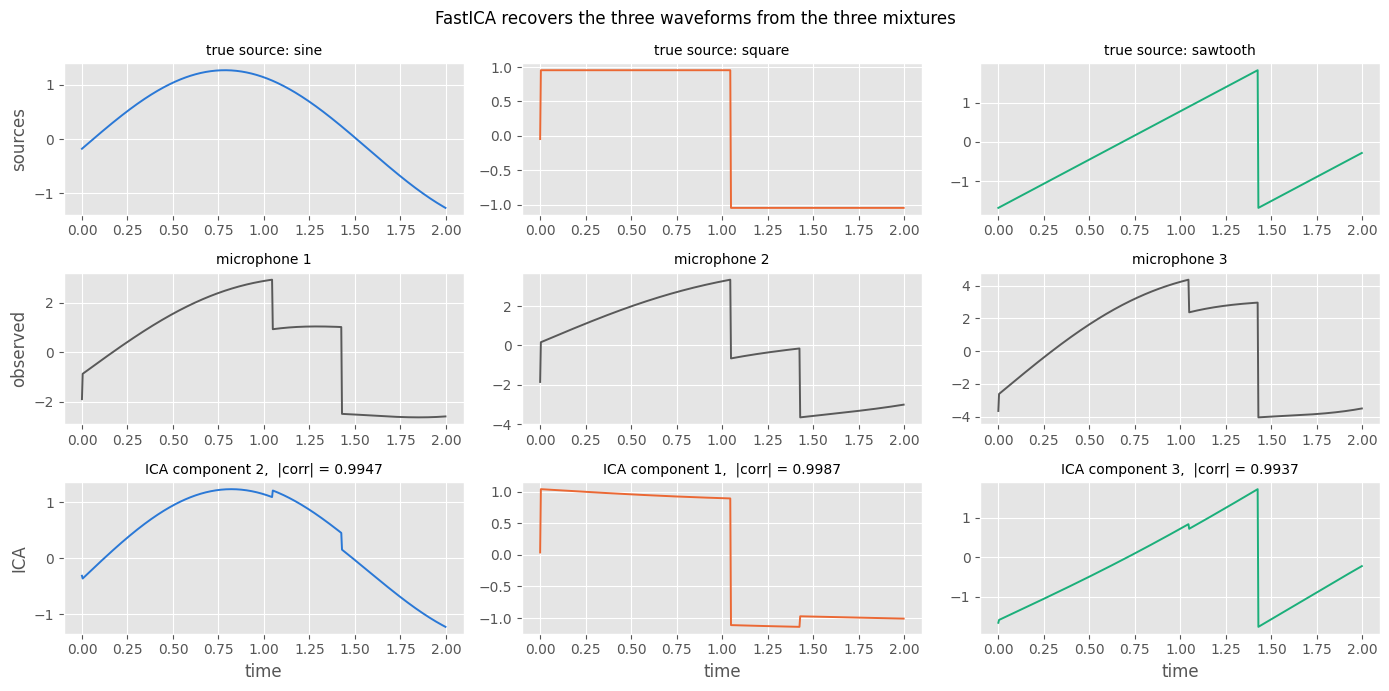

In [11]:
# scale and sign of each recovered signal are arbitrary; fix them for plotting only
signs = np.sign([np.corrcoef(S_ica[:, j], S_true[:, assign_ica[j]])[0, 1] for j in range(3)])
S_plot = (S_ica / S_ica.std(axis=0)) * signs

fig, ax = plt.subplots(3, 3, figsize=(14, 7))
window = slice(0, 500)

for j in range(3):
    ax[0, j].plot(t[window], S_true[window, j], color=COLOURS[j], lw=1.4)
    ax[0, j].set_title('true source: %s' % source_names[j], fontsize=10)

    ax[1, j].plot(t[window], X_mix[window, j], color='0.35', lw=1.4)
    ax[1, j].set_title('microphone %d' % (j + 1), fontsize=10)

    col = int(np.where(assign_ica == j)[0][0])
    ax[2, j].plot(t[window], S_plot[window, col], color=COLOURS[j], lw=1.4)
    ax[2, j].set_title('ICA component %d,  |corr| = %.4f' % (col + 1, corr_ica[col]), fontsize=10)
    ax[2, j].set_xlabel('time')

for row, label in enumerate(['sources', 'observed', 'ICA']):
    ax[row, 0].set_ylabel(label)

plt.suptitle('FastICA recovers the three waveforms from the three mixtures')
plt.tight_layout()
plt.show()

## The same mixture, given to PCA

This is the comparison that justifies the existence of ICA. PCA is applied to exactly the same three mixtures.
It produces three uncorrelated components — that part works perfectly, to machine precision — and they are not
the sources.

The reason is now clear. PCA is constrained only by second moments, so it delivers *some* uncorrelated basis;
whitening the data already achieves that, and PCA's particular choice among the infinitely many rotations of a
whitened dataset is made on variance, which has nothing to do with independence. The sources are one specific
rotation away, and only non-Gaussianity points to it.

In [12]:
Xc_mix = X_mix - X_mix.mean(axis=0)
_, _, Vt_mix = np.linalg.svd(Xc_mix, full_matrices=False)
S_pca = Xc_mix @ Vt_mix.T

C_pca, assign_pca, corr_pca = match_sources(S_pca, S_true)

print('PCA scores are uncorrelated: max |off-diagonal correlation| = %.2e'
      % np.abs(np.corrcoef(S_pca.T) - np.eye(3)).max())
print()
print('|correlation| between each method\'s components and each true source')
print('%-16s %10s %10s %10s' % ('', 'sine', 'square', 'sawtooth'))
for j in range(3):
    print('%-16s %10.4f %10.4f %10.4f' % ('PCA component %d' % (j + 1), *np.abs(C_pca[j])))
print()
for j in range(3):
    print('%-16s %10.4f %10.4f %10.4f' % ('ICA component %d' % (j + 1), *np.abs(match_sources(S_ica, S_true)[0][j])))
print()
print('best |corr| for any single source:  PCA %.4f %.4f %.4f' % tuple(np.abs(C_pca).max(axis=0)))
print('                                    ICA %.4f %.4f %.4f'
      % tuple(np.abs(match_sources(S_ica, S_true)[0]).max(axis=0)))
print()
print('Amari index of the global matrix:   PCA %.5f    ICA %.5f'
      % (amari_index(Vt_mix @ A_true), amari_ica))
print('(zero means a perfect scaled permutation; larger means the components are still mixed)')

PCA scores are uncorrelated: max |off-diagonal correlation| = 1.90e-15

|correlation| between each method's components and each true source
                       sine     square   sawtooth
PCA component 1      0.5214     0.6237     0.6256
PCA component 2      0.4225     0.7727     0.4161
PCA component 3      0.7414     0.1178     0.6598

ICA component 1      0.0657     0.9987     0.0570
ICA component 2      0.9947     0.0243     0.0961
ICA component 3      0.0795     0.0458     0.9937

best |corr| for any single source:  PCA 0.7414 0.7727 0.6598
                                    ICA 0.9947 0.9987 0.9937

Amari index of the global matrix:   PCA 0.40207    ICA 0.06215
(zero means a perfect scaled permutation; larger means the components are still mixed)


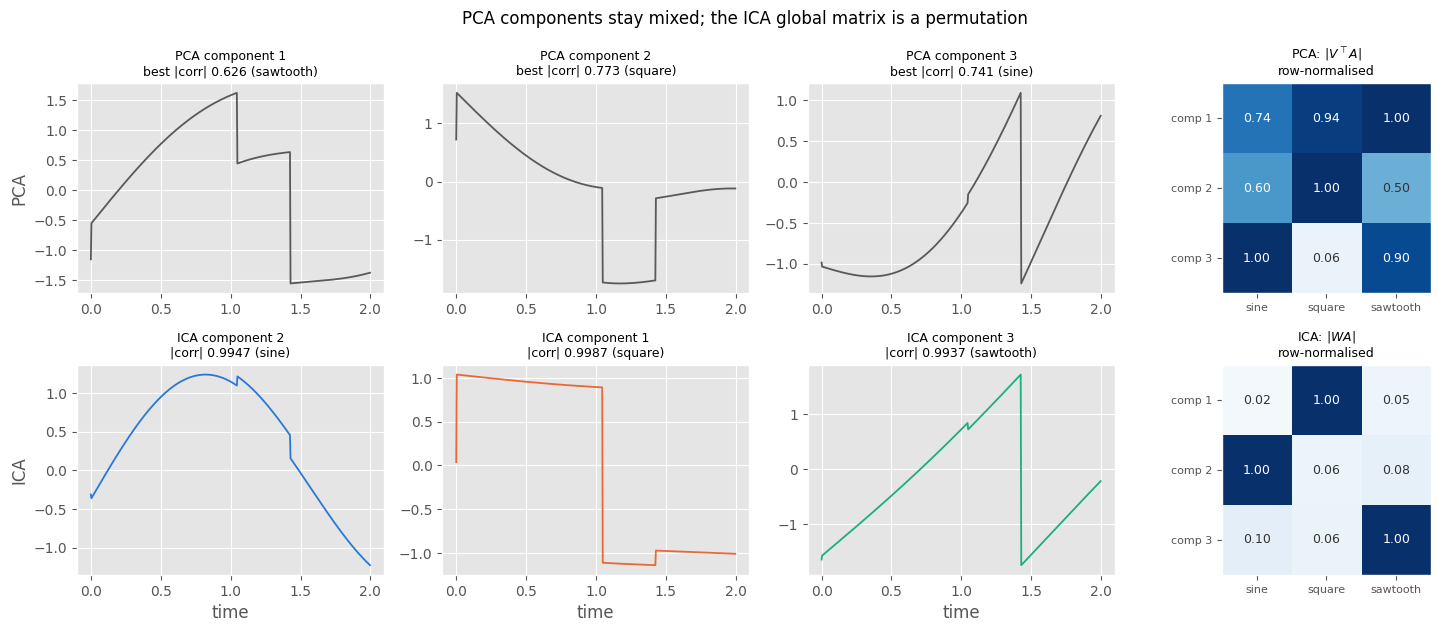

In [13]:
fig, ax = plt.subplots(2, 4, figsize=(15, 6.4))
window = slice(0, 500)

S_pca_plot = S_pca / S_pca.std(axis=0)

for j in range(3):
    ax[0, j].plot(t[window], S_pca_plot[window, j], color='0.35', lw=1.3)
    ax[0, j].set_title('PCA component %d\nbest |corr| %.3f (%s)'
                       % (j + 1, np.abs(C_pca[j]).max(), source_names[assign_pca[j]]), fontsize=9)
    col = int(np.where(assign_ica == j)[0][0])
    ax[1, j].plot(t[window], S_plot[window, col], color=COLOURS[j], lw=1.3)
    ax[1, j].set_title('ICA component %d\n|corr| %.4f (%s)'
                       % (col + 1, corr_ica[col], source_names[j]), fontsize=9)
    ax[1, j].set_xlabel('time')

for a, M, title in [(ax[0, 3], np.abs(Vt_mix @ A_true), 'PCA: $|V^\\top A|$'),
                    (ax[1, 3], np.abs(ica_main.unmixing @ A_true), 'ICA: $|WA|$')]:
    M = M / M.max(axis=1, keepdims=True)
    a.imshow(M, cmap='Blues', vmin=0, vmax=1)
    for p in range(3):
        for q in range(3):
            a.text(q, p, '%.2f' % M[p, q], ha='center', va='center', fontsize=9,
                   color='white' if M[p, q] > 0.6 else '0.2')
    a.set_xticks(range(3)); a.set_yticks(range(3))
    a.set_xticklabels(source_names, fontsize=8)
    a.set_yticklabels(['comp %d' % (i + 1) for i in range(3)], fontsize=8)
    a.set_title(title + '\nrow-normalised', fontsize=9)
    a.grid(False)

ax[0, 0].set_ylabel('PCA')
ax[1, 0].set_ylabel('ICA')
plt.suptitle('PCA components stay mixed; the ICA global matrix is a permutation')
plt.tight_layout()
plt.show()

Every PCA component is a visible blend of two or three waveforms. The best correlation any PCA component
achieves with any true source is 0.7727, and its global matrix has an Amari index of 0.40207 against ICA's
0.06215. The row-normalised heatmaps make the structure plain: ICA's $|WA|$ has one dominant entry per row and
per column, which is what a permutation looks like; PCA's $|V^\top A|$ has several comparable entries in every
row.

None of this is a failure of PCA. It solved the problem it was given, which was to find uncorrelated directions
ordered by variance, and the sources are not the directions of largest variance. It is a demonstration that
uncorrelated and independent are different requirements, and that the second one needs a different algorithm.

## What happens when the sources really are Gaussian

The argument above says Gaussian sources cannot be separated. Here is what that looks like when the algorithm is
run anyway.

Five independent datasets are generated from Gaussian sources through the same mixing matrix, and five from the
non-Gaussian waveforms with different phase offsets. FastICA is run on each with the same settings and seed, and
the Amari index of $WA$ is recorded. The non-Gaussian runs land near zero every time. The Gaussian runs do not,
and — more tellingly — they are all over the place, because each dataset's particular sampling noise picks out a
different arbitrary rotation. The algorithm converges perfectly well; it converges to nothing meaningful.

Amari index, Gaussian sources [0.5003 0.5559 0.358  0.5634 0.4265]
Amari index, real sources [0.0622 0.0542 0.0127 0.0322 0.0338]

mean over the five datasets:  Gaussian 0.4808    non-Gaussian 0.0390


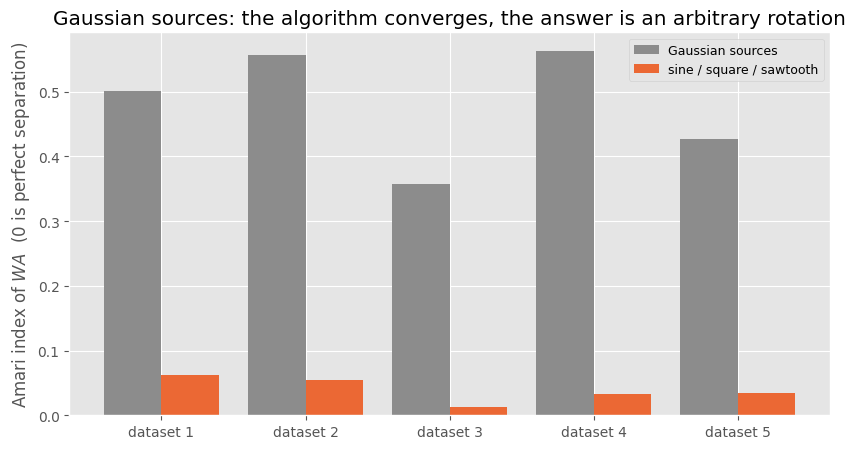

In [14]:
amari_gauss, amari_nongauss = [], []

for rep in range(5):
    r = np.random.default_rng(100 + rep)
    S_g = r.normal(size=(n_samples, 3))
    S_g = (S_g - S_g.mean(axis=0)) / S_g.std(axis=0)
    ica_g = Fast_ICA(seed=1).fit(S_g @ A_true.T)
    amari_gauss.append(amari_index(ica_g.unmixing @ A_true))

    tt = np.linspace(0, 8, n_samples) + rep * 0.37
    S_n = np.column_stack([np.sin(2 * tt), np.sign(np.sin(3 * tt)), 2 * ((tt * 0.7) % 1.0) - 1.0])
    S_n = (S_n - S_n.mean(axis=0)) / S_n.std(axis=0)
    ica_n = Fast_ICA(seed=1).fit(S_n @ A_true.T)
    amari_nongauss.append(amari_index(ica_n.unmixing @ A_true))

print('%-24s %s' % ('Amari index, Gaussian sources', np.array2string(np.round(amari_gauss, 4))))
print('%-24s %s' % ('Amari index, real sources', np.array2string(np.round(amari_nongauss, 4))))
print()
print('mean over the five datasets:  Gaussian %.4f    non-Gaussian %.4f'
      % (np.mean(amari_gauss), np.mean(amari_nongauss)))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
pos = np.arange(5)
ax.bar(pos - 0.2, amari_gauss, 0.4, color='0.55', label='Gaussian sources')
ax.bar(pos + 0.2, amari_nongauss, 0.4, color=orange, label='sine / square / sawtooth')
ax.set_xticks(pos)
ax.set_xticklabels(['dataset %d' % (i + 1) for i in pos])
ax.set_ylabel('Amari index of $WA$  (0 is perfect separation)')
ax.set_title('Gaussian sources: the algorithm converges, the answer is an arbitrary rotation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## The two ambiguities

Both follow directly from the model $\mathbf{x} = A\mathbf{s}$ and neither is a defect of the algorithm. No
method can do better, because the information is not in the data.

**Scale, including sign.** For any non-zero $\alpha_j$,

$$\mathbf{x} = \sum_j \mathbf{a}_j s_j = \sum_j \left(\frac{\mathbf{a}_j}{\alpha_j}\right)(\alpha_j s_j),$$

so multiplying a source by $\alpha_j$ and the corresponding column of $A$ by $1/\alpha_j$ leaves the observations
untouched. Since $\alpha_j$ may be negative, the sign of a recovered component is arbitrary too — which is why
every score above is $\lvert\text{corr}\rvert$ and why the plotted signals are sign-corrected for display. The
usual convention is to fix the ambiguity by giving each component unit variance, which is what the whitening
constraint $\lVert\mathbf{w}\rVert = 1$ already does. It does not fix the sign.

**Order.** For any permutation matrix $\Pi$,

$$\mathbf{x} = A\mathbf{s} = (A\Pi^\top)(\Pi\mathbf{s}),$$

so relabelling the sources and the columns of $A$ together is invisible. There is no "first" independent
component. PCA orders its components by variance and ICA has no equivalent, because after whitening every
direction has variance 1 by construction. Some implementations sort by kurtosis or by the value of the contrast
function, but that is a convention added on top rather than something the model provides.

The cell below runs the same fit from four random starts. The recovered sources are the same three waveforms
each time, to four decimals, but the order and the signs change from run to run.

In [15]:
print('%6s %26s %22s %10s' % ('seed', 'component -> source', 'signs', 'Amari'))
for seed in [1, 2, 3, 4]:
    ica_s = Fast_ICA(seed=seed).fit(X_mix)
    S_s = ica_s.transform(X_mix)
    C_s, assign_s, best_s = match_sources(S_s, S_true)
    signs_s = np.sign(C_s[np.arange(3), assign_s]).astype(int)
    order_str = ' '.join('%d->%s' % (j + 1, source_names[assign_s[j]][:4]) for j in range(3))
    print('%6d %26s %22s %10.5f'
          % (seed, order_str, np.array2string(signs_s), amari_index(ica_s.unmixing @ A_true)))

print()
print('the recovered waveforms are the same every time; only their order and sign move')
print('|corr| values, sorted, for each seed:')
for seed in [1, 2, 3, 4]:
    ica_s = Fast_ICA(seed=seed).fit(X_mix)
    _, _, best_s = match_sources(ica_s.transform(X_mix), S_true)
    print('  seed %d: %s' % (seed, np.array2string(np.round(np.sort(best_s), 5))))

  seed        component -> source                  signs      Amari
     1    1->squa 2->sine 3->sawt             [-1  1  1]    0.06215
     2    1->sine 2->sawt 3->squa             [ 1  1 -1]    0.06215
     3    1->sine 2->sawt 3->squa             [-1  1  1]    0.06215
     4    1->sawt 2->squa 3->sine                [1 1 1]    0.06215

the recovered waveforms are the same every time; only their order and sign move
|corr| values, sorted, for each seed:
  seed 1: [0.99374 0.99467 0.99866]
  seed 2: [0.99374 0.99467 0.99866]
  seed 3: [0.99374 0.99467 0.99866]
  seed 4: [0.99374 0.99467 0.99866]


## Convergence

The iteration is a Newton step, so it converges quickly and without a learning rate. The panel below tracks
$\lvert\,\lvert\mathbf{w}^{+\top}\mathbf{w}\rvert - 1\rvert$ for the symmetric algorithm under the three
nonlinearities, and the right-hand panel shows the deflationary version, where each component is found in turn
and later components converge faster because the Gram-Schmidt projection has already removed most of the space
they could move in.

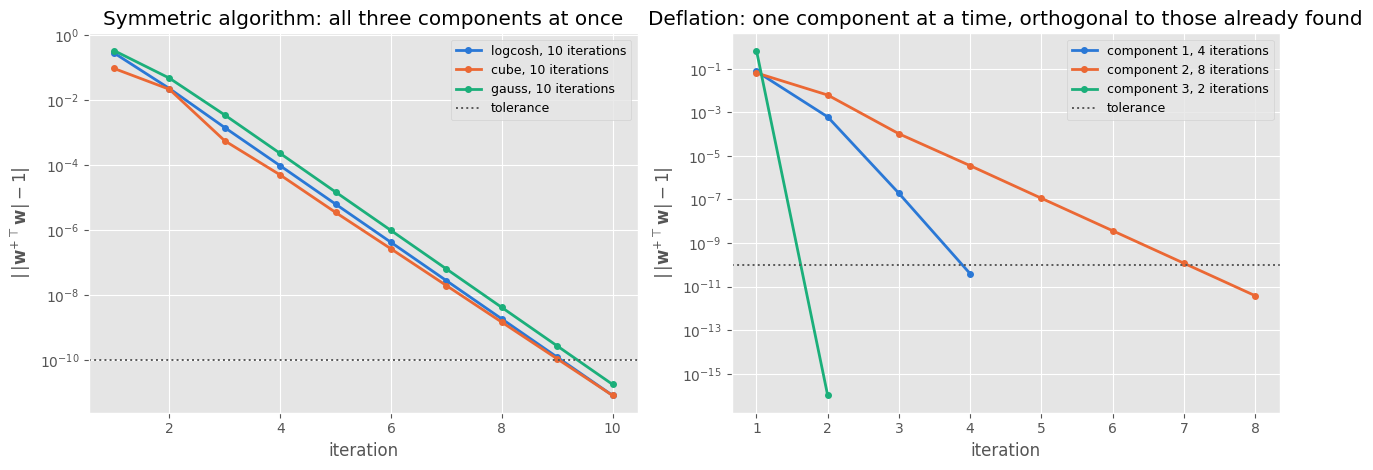

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

for fun, col in zip(['logcosh', 'cube', 'gauss'], COLOURS):
    ica_c = Fast_ICA(fun=fun, algorithm='parallel', seed=1).fit(X_mix)
    ax[0].semilogy(np.arange(1, len(ica_c.history) + 1), np.maximum(ica_c.history, 1e-16),
                   'o-', color=col, lw=2, ms=4, label='%s, %d iterations' % (fun, ica_c.n_iter))

ax[0].axhline(1e-10, color='0.35', ls=':', lw=1.4, label='tolerance')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel(r'$\left|\,|\mathbf{w}^{+\top}\mathbf{w}| - 1\right|$')
ax[0].set_title('Symmetric algorithm: all three components at once')
ax[0].legend(fontsize=9)

ica_d = Fast_ICA(fun='logcosh', algorithm='deflation', seed=1).fit(X_mix)
for j, col in enumerate(COLOURS[:3]):
    h = np.maximum(ica_d.history[j], 1e-16)
    ax[1].semilogy(np.arange(1, len(h) + 1), h, 'o-', color=col, lw=2, ms=4,
                   label='component %d, %d iterations' % (j + 1, ica_d.n_iter[j]))
ax[1].axhline(1e-10, color='0.35', ls=':', lw=1.4, label='tolerance')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel(r'$\left|\,|\mathbf{w}^{+\top}\mathbf{w}| - 1\right|$')
ax[1].set_title('Deflation: one component at a time, orthogonal to those already found')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## On the handwritten digits

The signal example has a known mixing matrix, which is what made scoring possible. Real data does not, so the
last section runs ICA on the UCI digits used by `pca.ipynb` and `tsne.ipynb` — 4,496 training images of 8x8
pixels — where the question is no longer "did it recover the truth" but "what does it produce that PCA does
not".

The setup is 20 components. The data is whitened onto the leading 20 principal directions first, so ICA is
searching for a rotation inside precisely the subspace PCA selected. That has an immediate consequence worth
stating before the numbers: **ICA does not change the reconstruction error at all.** Rotating an orthonormal
basis of a subspace does not change the subspace, so reconstructing from 20 independent components and from 20
principal components gives identical images. Whatever ICA is doing, it is not compressing better.

What changes is the coordinates. The scores are compared on excess kurtosis, which is what the contrast function
was maximising, and the basis images are drawn side by side.

In [17]:
digits = fetch_ucirepo(id=80)
X_all = digits.data.features.values.astype(float) / 16.0
y_all = digits.data.targets.values.ravel()

rng_split = np.random.default_rng(0)
order = rng_split.permutation(len(X_all))
split = int(0.8 * len(X_all))
X_train, y_train = X_all[order[:split]], y_all[order[:split]]

K_COMP = 20
start = time.time()
ica_digits = Fast_ICA(n_components=K_COMP, fun='logcosh', algorithm='parallel',
                      max_iter=1000, seed=1).fit(X_train)
S_digits = ica_digits.transform(X_train)
elapsed = time.time() - start

mean_d = X_train.mean(axis=0)
Xc_d = X_train - mean_d
_, _, Vt_d = np.linalg.svd(Xc_d, full_matrices=False)
V_d = Vt_d.T[:, :K_COMP]
Z_pca_d = Xc_d @ V_d

R_ica = ica_digits.inverse_transform(S_digits)
R_pca = mean_d + Z_pca_d @ V_d.T

print('training images %d x %d, %d components, %d iterations, %.1f s'
      % (X_train.shape[0], X_train.shape[1], K_COMP, ica_digits.n_iter, elapsed))
print()
print('reconstruction error from 20 components')
print('  ICA %.5f' % np.mean(np.sum((X_train - R_ica) ** 2, axis=1)))
print('  PCA %.5f' % np.mean(np.sum((X_train - R_pca) ** 2, axis=1)))
print('  largest per-image difference between the two reconstructions: %.2e'
      % np.abs(R_ica - R_pca).max())
print()
k_ica = excess_kurtosis(S_digits)
k_pca = excess_kurtosis(Z_pca_d)
print('excess kurtosis of the 20 scores')
print('  ICA   mean %6.3f   median %6.3f   min %6.3f   max %6.3f'
      % (k_ica.mean(), np.median(k_ica), k_ica.min(), k_ica.max()))
print('  PCA   mean %6.3f   median %6.3f   min %6.3f   max %6.3f'
      % (k_pca.mean(), np.median(k_pca), k_pca.min(), k_pca.max()))
print()
print('mutual information over all %d score pairs' % (K_COMP * (K_COMP - 1) // 2))
for name, Zs in [('ICA', S_digits), ('PCA', Z_pca_d)]:
    mis = [mutual_information(Zs[:, i], Zs[:, j], bins=16)
           for i in range(K_COMP) for j in range(i + 1, K_COMP)]
    print('  %s  mean %.5f   max %.5f nats' % (name, np.mean(mis), np.max(mis)))


def concentration(M):
    # fraction of a basis image's squared energy held by its eight strongest pixels
    e = M ** 2
    e = e / e.sum(axis=0, keepdims=True)
    return np.sort(e, axis=0)[::-1][:8].sum(axis=0)


print()
print('how concentrated the basis images are (energy in the top 8 of 64 pixels)')
print('  ICA %.4f      PCA %.4f' % (concentration(ica_digits.mixing).mean(), concentration(V_d).mean()))

training images 4496 x 64, 20 components, 173 iterations, 0.1 s

reconstruction error from 20 components
  ICA 0.50285
  PCA 0.50285
  largest per-image difference between the two reconstructions: 1.06e-13

excess kurtosis of the 20 scores
  ICA   mean  2.504   median  2.046   min -0.460   max  6.637
  PCA   mean -0.039   median  0.025   min -1.134   max  0.438

mutual information over all 190 score pairs
  ICA  mean 0.03664   max 0.11556 nats
  PCA  mean 0.04629   max 0.19366 nats

how concentrated the basis images are (energy in the top 8 of 64 pixels)
  ICA 0.5891      PCA 0.6245


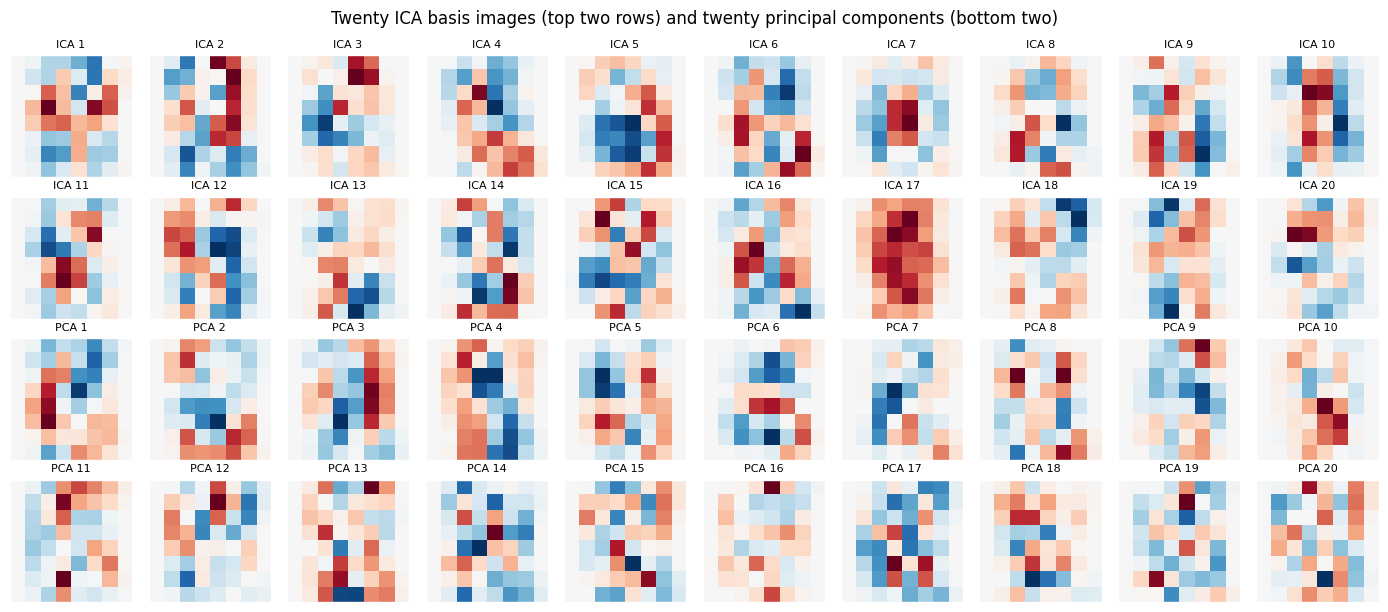

In [18]:
A_ica = ica_digits.mixing        # columns are the basis images ICA adds together

fig, ax = plt.subplots(4, 10, figsize=(14, 6.2))

# order both sets by how much each score varies, so the panels are comparable
ica_order = np.argsort(S_digits.std(axis=0))[::-1]

for j in range(10):
    for row, img, name in [(0, A_ica[:, ica_order[j]], 'ICA'), (2, V_d[:, j], 'PCA')]:
        lim = np.abs(img).max()
        a = ax[row, j]
        a.imshow(img.reshape(8, 8), cmap='RdBu_r', vmin=-lim, vmax=lim)
        a.set_title('%s %d' % (name, j + 1), fontsize=8)
    for row, img, name in [(1, A_ica[:, ica_order[j + 10]], 'ICA'), (3, V_d[:, j + 10], 'PCA')]:
        lim = np.abs(img).max()
        a = ax[row, j]
        a.imshow(img.reshape(8, 8), cmap='RdBu_r', vmin=-lim, vmax=lim)
        a.set_title('%s %d' % (name, j + 11), fontsize=8)

for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('Twenty ICA basis images (top two rows) and twenty principal components (bottom two)')
plt.tight_layout()
plt.show()

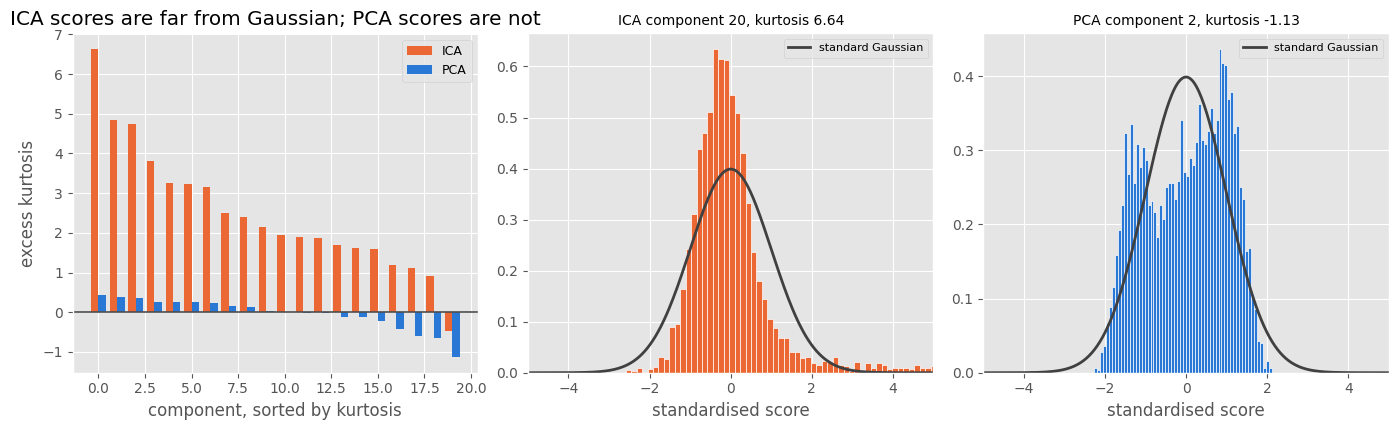

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))

idx = np.arange(K_COMP)
ax[0].bar(idx - 0.2, np.sort(k_ica)[::-1], 0.4, color=orange, label='ICA')
ax[0].bar(idx + 0.2, np.sort(k_pca)[::-1], 0.4, color=blue, label='PCA')
ax[0].axhline(0, color='0.3', lw=1.2)
ax[0].set_xlabel('component, sorted by kurtosis')
ax[0].set_ylabel('excess kurtosis')
ax[0].set_title('ICA scores are far from Gaussian; PCA scores are not')
ax[0].legend(fontsize=9)

top_ica = int(np.argmax(k_ica))
top_pca = int(np.argmax(np.abs(k_pca)))
for a, values, col, title in [(ax[1], S_digits[:, top_ica] / S_digits[:, top_ica].std(), orange,
                               'ICA component %d, kurtosis %.2f' % (top_ica + 1, k_ica[top_ica])),
                              (ax[2], Z_pca_d[:, top_pca] / Z_pca_d[:, top_pca].std(), blue,
                               'PCA component %d, kurtosis %.2f' % (top_pca + 1, k_pca[top_pca]))]:
    a.hist(values, bins=60, color=col, edgecolor='white', density=True)
    grid_x = np.linspace(-5, 5, 300)
    a.plot(grid_x, np.exp(-grid_x ** 2 / 2) / np.sqrt(2 * np.pi), color='0.25', lw=2,
           label='standard Gaussian')
    a.set_xlim(-5, 5)
    a.set_title(title, fontsize=10)
    a.set_xlabel('standardised score')
    a.legend(fontsize=8)

plt.tight_layout()
plt.show()

The scores tell the story the contrast function promised. The twenty ICA scores have a mean excess kurtosis of
2.504 against the PCA scores' -0.039: an ICA score is near zero for most digits and large for a few, while a PCA
score is spread over all of them in a shape close to a bell curve. That is the practical meaning of maximising
non-Gaussianity on data like this — the components become detectors that fire on a subset of images rather than
descriptions of overall variation.

The basis images are the part to be careful about. Both sets are contrasts between regions of the 8x8 grid, and
the ICA ones are not more localised than the principal components — measuring it, the eight strongest pixels of
an ICA basis image hold 58.9% of its energy against 62.5% for a principal component, so if anything the ICA
basis is the more spread out of the two. The honest summary is that on 64-pixel digits ICA changes what the *scores*
look like much more than it changes what the *basis* looks like. The strong claims about ICA producing localised,
part-like features come from data with far more pixels and far more structure, and it would be wrong to read
them into this figure.

The pairwise mutual information between scores drops as well, from a mean of 0.046 nats for PCA to 0.037 for
ICA, and from a worst pair of 0.194 to 0.116. The reduction is real but modest, which is the correct impression
to take away: with 20 components estimated from 4,496 images there is a limit to how independent the outputs
can be made, and the histogram estimator itself has a floor.

The reconstruction check confirms the framing at the top of the section: the two reconstructions agree to about
$10^{-13}$ per pixel. ICA is not a dimensionality reduction method. It takes the subspace as given — usually
from PCA — and re-chooses the axes on it.

## Summary

In [20]:
print('%-48s %s' % ('sources / mixtures', '%d samples, %d channels' % X_mix.shape))
print('%-48s %s' % ('ICA |corr| with the true sources', np.array2string(np.round(np.sort(corr_ica)[::-1], 4))))
print('%-48s %s' % ('PCA best |corr| per source', np.array2string(np.round(np.abs(C_pca).max(axis=0), 4))))
print('%-48s %.5f' % ('Amari index, ICA', amari_ica))
print('%-48s %.5f' % ('Amari index, PCA', amari_index(Vt_mix @ A_true)))
print('%-48s %.5f' % ('Amari index, Gaussian sources (mean of 5)', np.mean(amari_gauss)))
print('%-48s %.5f' % ('MI spread over rotations, uniform sources',
                      curves['uniform'].max() - curves['uniform'].min()))
print('%-48s %.5f' % ('MI spread over rotations, Gaussian sources',
                      curves['gaussian'].max() - curves['gaussian'].min()))
print('%-48s %.3f' % ('mean kurtosis, 20 ICA scores on digits', k_ica.mean()))
print('%-48s %.3f' % ('mean kurtosis, 20 PCA scores on digits', k_pca.mean()))
print()
print('total notebook runtime: %.1f s' % (time.time() - notebook_start))

sources / mixtures                               2000 samples, 3 channels
ICA |corr| with the true sources                 [0.9987 0.9947 0.9937]
PCA best |corr| per source                       [0.7414 0.7727 0.6598]
Amari index, ICA                                 0.06215
Amari index, PCA                                 0.40207
Amari index, Gaussian sources (mean of 5)        0.48082
MI spread over rotations, uniform sources        0.25378
MI spread over rotations, Gaussian sources       0.00239
mean kurtosis, 20 ICA scores on digits           2.504
mean kurtosis, 20 PCA scores on digits           -0.039

total notebook runtime: 8.3 s


- ICA fits $\mathbf{x} = A\mathbf{s}$ by finding the linear map whose outputs are as **statistically
  independent** as possible, which is a strictly stronger requirement than the uncorrelatedness PCA delivers.
  On three mixed waveforms it recovered every source with $\lvert\text{corr}\rvert$ of 0.9987, 0.9947 and
  0.9937, and an Amari index of 0.062. PCA, given the identical data, produced perfectly uncorrelated components
  whose best correlation with any source was 0.773, at an Amari index of 0.402.
- **Gaussian sources cannot be separated, ever.** A rotation of independent standard Gaussians is again
  independent standard Gaussians, and $\mathbf{x} = A\mathbf{s} = (AR^\top)(R\mathbf{s})$ gives the identical
  distribution of observations, so independence cannot choose between them. Measured: the mutual information of
  a rotated Gaussian pair varies by 0.002 nats over all rotations, against 0.254 for a uniform pair; and over
  five Gaussian datasets FastICA returned Amari indices from 0.358 to 0.563, a different arbitrary rotation each
  time, while the same five non-Gaussian datasets gave 0.013 to 0.062.
- **Non-Gaussianity is the contrast**, because $\mathbf{w}^\top\mathbf{x} = \mathbf{q}^\top\mathbf{s}$ is a sum
  of independent sources and is therefore more Gaussian than any single one of them. The three sources here have
  excess kurtosis $-1.365$, $-1.991$ and $-1.151$; the three mixtures, $-0.436$, $-1.174$ and $-0.420$.
- **Whitening is PCA doing ICA's setup work.** After it, the residual mixing matrix must be orthogonal —
  which held to 4.7e-14 once the sources' residual sample correlation of 0.086 was removed — so the search is
  over $D(D-1)/2$ rotation parameters rather than $D^2$ matrix
  entries, and the iterates can be kept orthonormal throughout.
- **The FastICA update is a Newton step with the Jacobian approximated by a scalar**, giving
  $\mathbf{w}^{+} = \mathbb{E}\{\mathbf{z}g(\mathbf{w}^\top\mathbf{z})\} - \mathbb{E}\{g'(\mathbf{w}^\top\mathbf{z})\}\mathbf{w}$
  with no step size to tune. It converged in 10 symmetric iterations here, and all three nonlinearities and both
  orthogonalisation schemes agreed on the answer.
- **Order and scale are not identifiable.** $A\Pi^\top\Pi\mathbf{s}$ and $(\mathbf{a}_j/\alpha_j)(\alpha_j s_j)$
  leave the observations unchanged, so there is no first component and no correct sign. Four random starts gave
  four different orderings and sign patterns with identical waveforms.
- **ICA does not reduce dimension.** On the digits it rotates within the 20-dimensional PCA subspace and returns
  an identical reconstruction to $10^{-13}$, while changing the mean excess kurtosis of the scores from -0.039
  to 2.504.

The remaining limitation is that the mixing is assumed linear, instantaneous and square. Data whose structure is
a curved manifold rather than a linear mixture is not what this model describes, and `tsne.ipynb` takes up that
case.